In [1]:
!pip install scikit-learn pandas numpy matplotlib

In [14]:
np.random.seed(42)
n = 120

healthy = pd.DataFrame({
    "NDVI (800/670)": np.random.normal(0.68, 0.18, n),
    "GNDVI":          np.random.normal(0.55, 0.16, n),
    "RVI":            np.random.normal(5.8,  2.1,  n),
    "WI":             np.random.normal(1.07, 0.07, n),
    "NDWI":           np.random.normal(0.036, 0.018, n),
    "SIPI":           np.random.normal(1.08, 0.16, n),
    "PRI":            np.random.normal(0.042, 0.025, n),
    "ARI":            np.random.normal(1.30, 0.60, n),
    "CARI":           np.random.normal(0.82, 0.22, n),
    "label": 1,
})
diseased = pd.DataFrame({
    "NDVI (800/670)": np.random.normal(0.52, 0.18, n),
    "GNDVI":          np.random.normal(0.43, 0.16, n),
    "RVI":            np.random.normal(3.8,  1.8,  n),
    "WI":             np.random.normal(1.01, 0.07, n),
    "NDWI":           np.random.normal(0.026, 0.014, n),
    "SIPI":           np.random.normal(1.20, 0.16, n),
    "PRI":            np.random.normal(0.018, 0.022, n),
    "ARI":            np.random.normal(2.00, 0.55, n),
    "CARI":           np.random.normal(0.68, 0.20, n),
    "label": 0,
})


df = pd.concat([healthy, diseased], ignore_index=True)
print(f"Dataset: {len(df)} samples, {df['label'].value_counts().to_dict()}")
df.head()

Dataset: 240 samples, {1: 120, 0: 120}


,NDVI (800/670),GNDVI,RVI,WI,NDWI,SIPI,PRI,ARI,CARI,label
0,0.769409,0.676565,4.135706,1.106354,0.033697,1.201118,0.049695,1.270322,0.961399,1
1,0.655112,0.404498,5.559053,1.177292,0.018800,0.932454,-0.000754,1.704892,1.112414,1
2,0.796584,0.774447,6.860473,1.062387,0.007084,1.219137,0.008295,0.626367,0.863235,1
3,0.954145,0.325704,7.618086,1.098120,0.039662,1.296902,0.060582,1.529446,0.975981,1
4,0.637852,0.643897,3.279378,1.118310,0.022386,1.146150,0.046272,1.399871,0.800258,1


In [15]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

feature_cols = ["NDVI (800/670)", "GNDVI", "RVI", "WI", "NDWI", "SIPI", "PRI", "ARI", "CARI"]
X = df[feature_cols]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

models = {
    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_leaf=5))
    ]),
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
    ]),
    "NN (small MLP)": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(hidden_layer_sizes=(16,), max_iter=1000, random_state=42))
    ]),
    "NN (medium MLP)": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=1500, random_state=42))
    ]),
    "NN (deeper MLP)": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(hidden_layer_sizes=(64, 32, 16), max_iter=2000, random_state=42))
    ]),
}

results = []
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall":    round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1":        round(f1_score(y_test, y_pred, zero_division=0), 4),
        "ROC_AUC":   round(roc_auc_score(y_test, y_proba), 4),
    })
    print(f"\n{name}")
    print(classification_report(y_test, y_pred, target_names=["Diseased", "Healthy"]))

pd.DataFrame(results).sort_values("F1", ascending=False)


Decision Tree
              precision    recall  f1-score   support

    Diseased       0.90      0.75      0.82        24
     Healthy       0.79      0.92      0.85        24

    accuracy                           0.83        48
   macro avg       0.84      0.83      0.83        48
weighted avg       0.84      0.83      0.83        48


Logistic Regression
              precision    recall  f1-score   support

    Diseased       0.88      0.88      0.88        24
     Healthy       0.88      0.88      0.88        24

    accuracy                           0.88        48
   macro avg       0.88      0.88      0.88        48
weighted avg       0.88      0.88      0.88        48



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(



NN (small MLP)
              precision    recall  f1-score   support

    Diseased       0.91      0.83      0.87        24
     Healthy       0.85      0.92      0.88        24

    accuracy                           0.88        48
   macro avg       0.88      0.88      0.87        48
weighted avg       0.88      0.88      0.87        48


NN (medium MLP)
              precision    recall  f1-score   support

    Diseased       0.91      0.88      0.89        24
     Healthy       0.88      0.92      0.90        24

    accuracy                           0.90        48
   macro avg       0.90      0.90      0.90        48
weighted avg       0.90      0.90      0.90        48


NN (deeper MLP)
              precision    recall  f1-score   support

    Diseased       0.91      0.83      0.87        24
     Healthy       0.85      0.92      0.88        24

    accuracy                           0.88        48
   macro avg       0.88      0.88      0.87        48
weighted avg       0.88 

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
3,NN (medium MLP),0.8958,0.8800,0.9167,0.8980,0.8976
4,NN (deeper MLP),0.8750,0.8462,0.9167,0.8800,0.8993
2,NN (small MLP),0.8750,0.8462,0.9167,0.8800,0.8802
1,Logistic Regression,0.8750,0.8750,0.8750,0.8750,0.8889
0,Decision Tree,0.8333,0.7857,0.9167,0.8462,0.8681


In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"accuracy":"accuracy","precision":"precision","recall":"recall","f1":"f1","roc_auc":"roc_auc"}

cv_summary = []
for name, pipe in models.items():
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring)
    cv_summary.append({
        "Model":       name,
        "CV F1":       round(scores["test_f1"].mean(), 4),
        "CV F1 std":   round(scores["test_f1"].std(), 4),
        "CV ROC_AUC":  round(scores["test_roc_auc"].mean(), 4),
    })

pd.DataFrame(cv_summary).sort_values("CV F1", ascending=False)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,CV F1,CV F1 std,CV ROC_AUC
1,Logistic Regression,0.8624,0.0416,0.9278
2,NN (small MLP),0.8407,0.0305,0.9125
4,NN (deeper MLP),0.8282,0.0331,0.8698
3,NN (medium MLP),0.8062,0.0360,0.8691
0,Decision Tree,0.7483,0.0485,0.7790


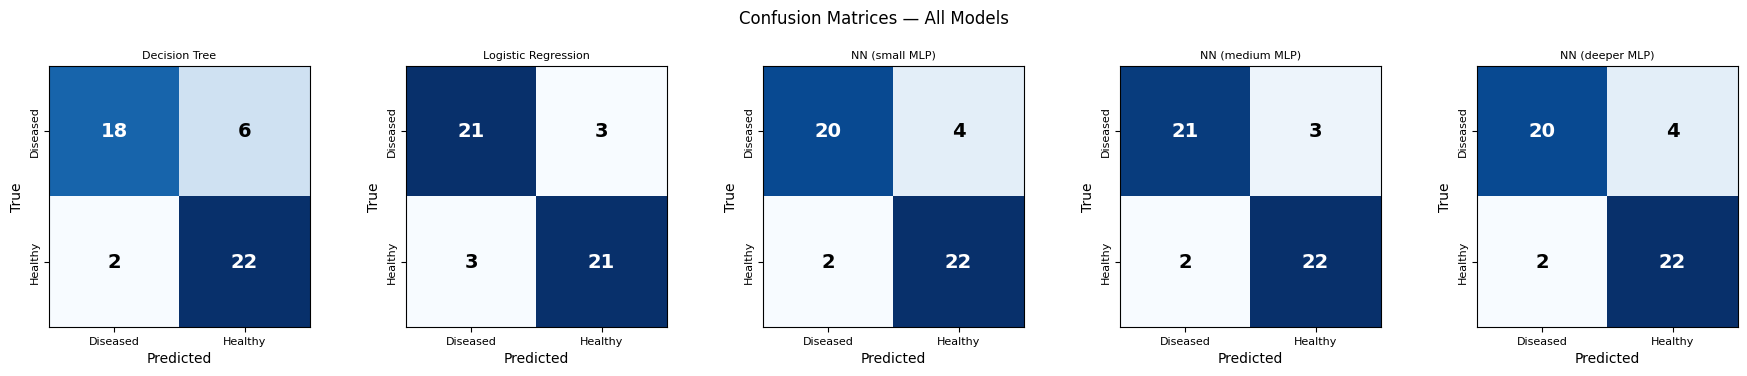

In [17]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 5, figsize=(18, 3.5))
for ax, (name, pipe) in zip(axes, models.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(["Diseased","Healthy"], fontsize=8)
    ax.set_yticklabels(["Diseased","Healthy"], fontsize=8, rotation=90, va="center")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i,j], ha="center", va="center",
                    color="white" if cm[i,j] > cm.max()/2 else "black",
                    fontsize=14, fontweight="bold")
    ax.set_title(name, fontsize=8)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.suptitle("Confusion Matrices — All Models", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

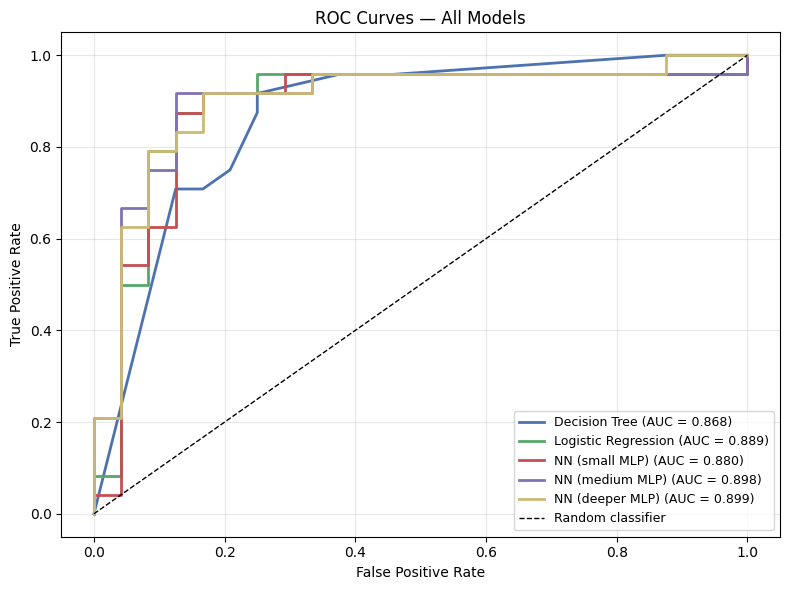

In [18]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]

for (name, pipe), color in zip(models.items(), colors):
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f"{name} (AUC = {roc_auc:.3f})")

ax.plot([0,1], [0,1], "k--", linewidth=1, label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Models")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

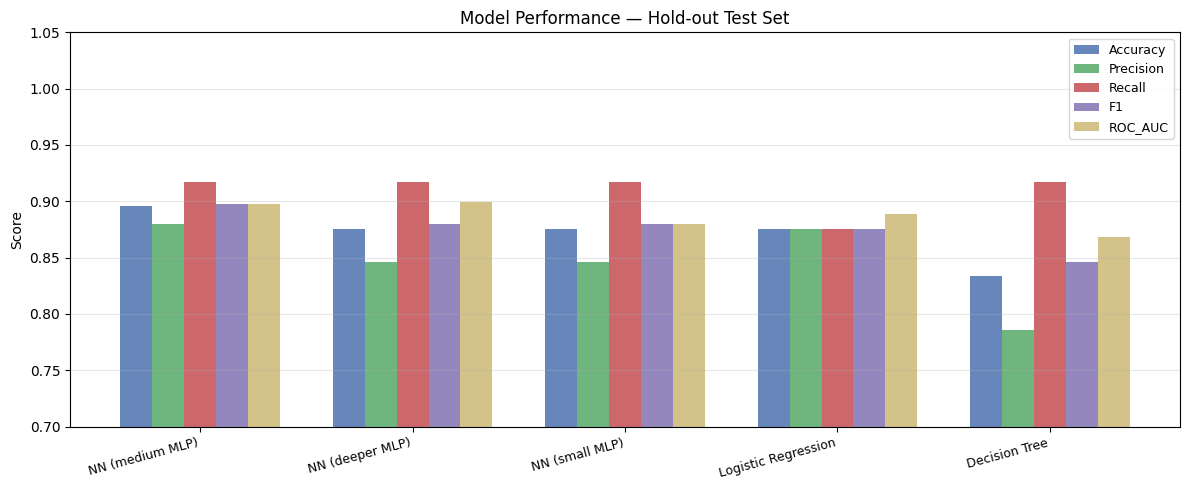

In [19]:
results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
x = np.arange(len(results_df))
width = 0.15
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]

fig, ax = plt.subplots(figsize=(12, 5))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i*width, results_df[metric], width,
                  label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width*2)
ax.set_xticklabels(results_df["Model"], rotation=15, ha="right", fontsize=9)
ax.set_ylim(0.70, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model Performance — Hold-out Test Set")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipykernel_7391/182122629.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cv_df["Model"], rotation=15, ha="right", fontsize=9)


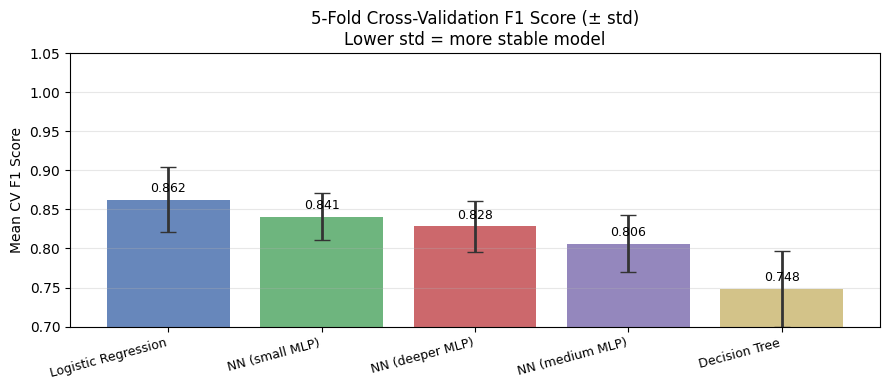

In [20]:
cv_df = pd.DataFrame(cv_summary).sort_values("CV F1", ascending=False)
colors_cv = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#CCB974"]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(cv_df["Model"], cv_df["CV F1"],
              yerr=cv_df["CV F1 std"],
              color=colors_cv, capsize=6, alpha=0.85,
              error_kw={"linewidth": 2, "ecolor": "#333333"})
for bar, val in zip(bars, cv_df["CV F1"]):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.006,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0.70, 1.05)
ax.set_ylabel("Mean CV F1 Score")
ax.set_title("5-Fold Cross-Validation F1 Score (± std)\nLower std = more stable model")
ax.set_xticklabels(cv_df["Model"], rotation=15, ha="right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

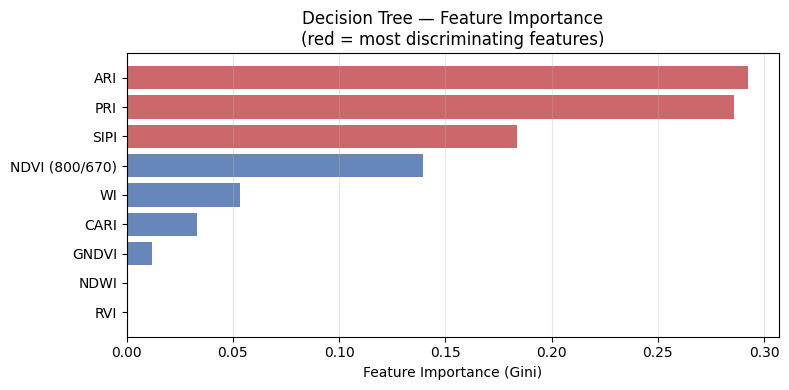

In [21]:
dt_pipe = models["Decision Tree"]
importances = dt_pipe.named_steps["model"].feature_importances_
sorted_idx = np.argsort(importances)
colors_fi = ["#C44E52" if importances[i] > 0.15 else "#4C72B0" for i in sorted_idx]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh([feature_cols[i] for i in sorted_idx], importances[sorted_idx],
        color=colors_fi, alpha=0.85)
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title("Decision Tree — Feature Importance\n(red = most discriminating features)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

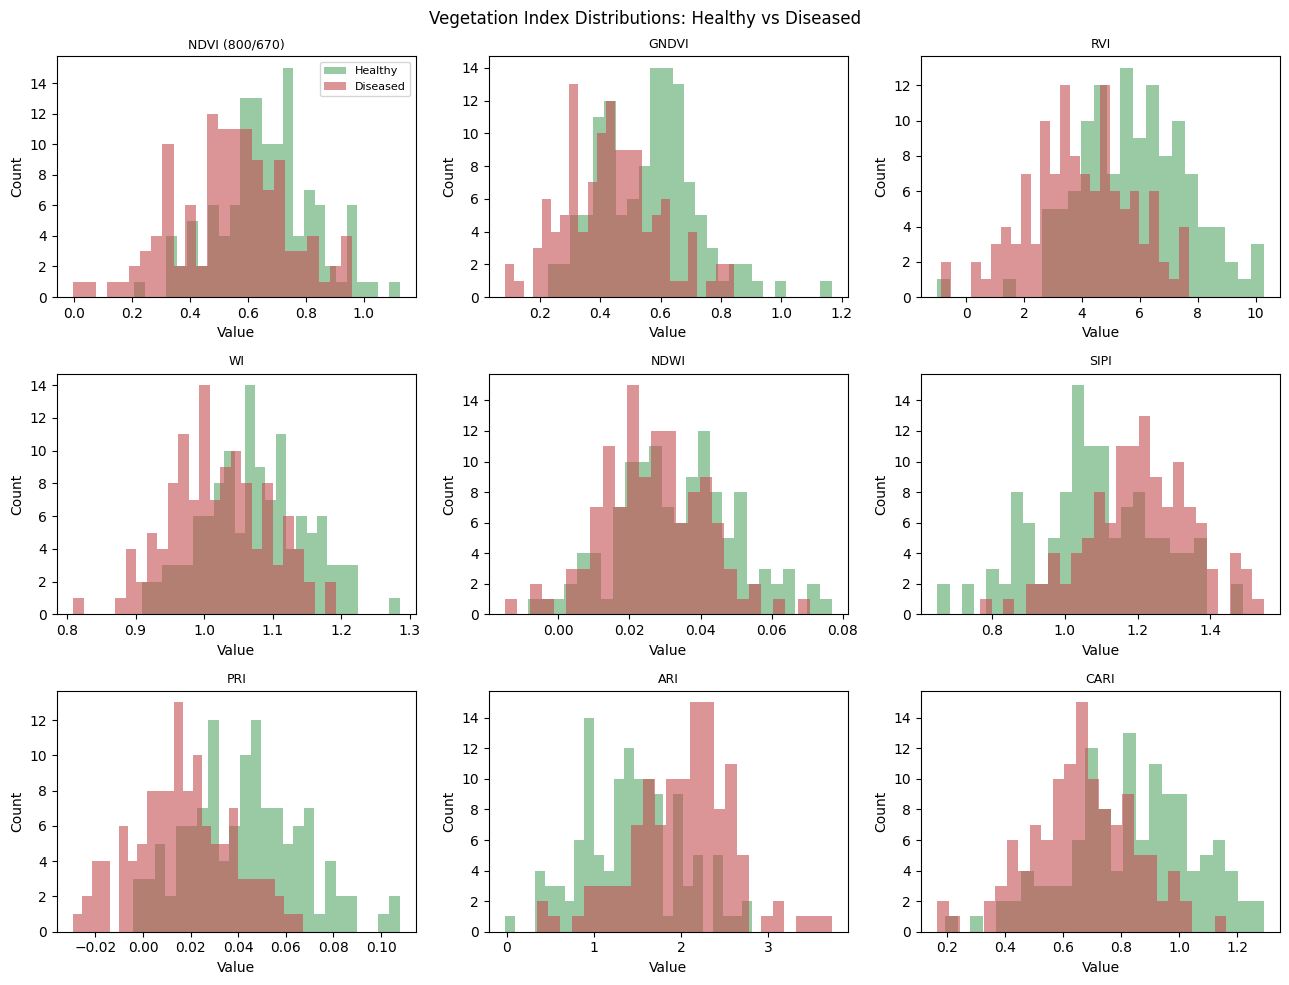

In [24]:
fig, axes = plt.subplots(3, 3, figsize=(13, 10))
axes = axes.flatten()

for i, feat in enumerate(feature_cols):
    h_vals = df[df["label"]==1][feat]
    d_vals = df[df["label"]==0][feat]
    axes[i].hist(h_vals, bins=25, alpha=0.6, color="#55A868", label="Healthy")
    axes[i].hist(d_vals, bins=25, alpha=0.6, color="#C44E52", label="Diseased")
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle("Vegetation Index Distributions: Healthy vs Diseased", fontsize=12)
plt.tight_layout()
plt.show()

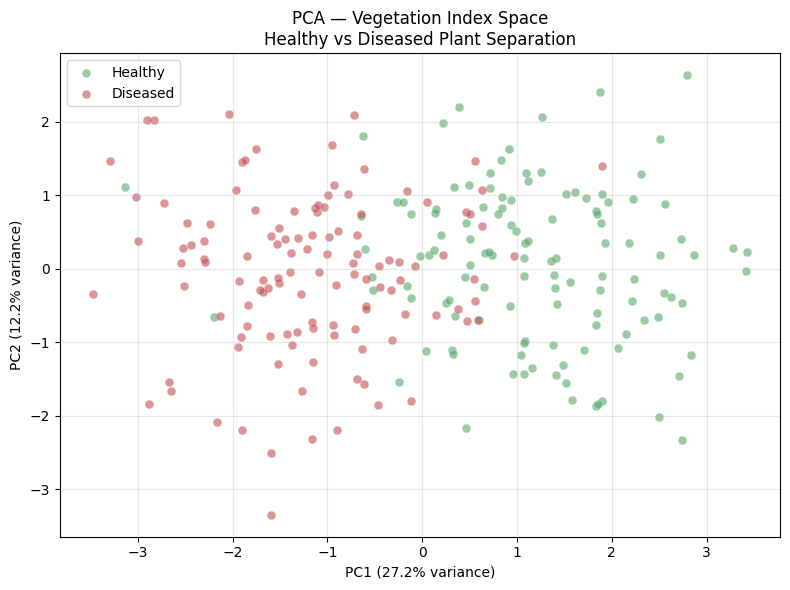

In [25]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
var = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(8, 6))
for label, name, color in [(1, "Healthy", "#55A868"), (0, "Diseased", "#C44E52")]:
    mask = y == label
    ax.scatter(coords[mask, 0], coords[mask, 1],
               c=color, label=name, alpha=0.6, s=40, edgecolors="white", linewidth=0.3)

ax.set_xlabel(f"PC1 ({var[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({var[1]:.1f}% variance)")
ax.set_title("PCA — Vegetation Index Space\nHealthy vs Diseased Plant Separation")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()